In [1]:
# Relative paths - portable across machines after cloning the repository
from pathlib import Path

DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")


---

## Airline Reviews — ML, Halo Effect, T-test, LDA Topics

*Source notebook: `notebook_eda V2.ipynb`*


# Bảng Phân tích tổng quan dữ liệu bên cạnh SQL
### Nhóm 1: Thống kê Tương quan & Phân phối (Statistical Correlation & Distribution)
#### 🐍 1.1. Tiêu chí dịch vụ nào có sức nặng lớn nhất ảnh hưởng đến quyết định Khuyến nghị (Recommended)? _(Trả lời câu hỏi quan trọng nhất số 1 của bạn bằng Toán học)_
#### 🐍 1.2. Sơ đồ bố trí ghế (Seat Layout - ví dụ 3x3 vs 2x4x2) ảnh hưởng thế nào đến cảm nhận về độ rộng (Seat Width) và chỗ để chân (Legroom)?
### Nhóm 2: Khai phá Ngôn ngữ Tự nhiên & Tiếng nói Khách hàng (NLP & VoC Deep-dive)
#### 🐍 2.1. Top từ khóa "Khét tiếng" nhất xuất hiện trong các bài review 1 Sao / Tiêu cực là gì? _(Mở rộng từ câu 4 của bạn)_
2.2. Phân tích Quỹ đạo Cảm xúc (Sentiment Trajectory): Chất lượng dịch vụ phục hồi hay suy thoái sau giai đoạn đại dịch

✔️ Số lượng review ĐÃ XÁC THỰC đưa vào mô hình: 20,644 dòng

BẢNG XẾP HẠNG ĐỘ QUAN TRỌNG CỦA CÁC DỊCH VỤ:
               Dịch_vụ  Độ_quan_trọng_%
       value_for_money        39.585211
        ground_service        23.081962
          seat_comfort        14.118856
   cabin_staff_service        12.237195
    food_and_beverages         7.987011
inflight_entertainment         2.471158
 wifi_and_connectivity         0.518607


C:\Users\luong\AppData\Local\Temp\ipykernel_17488\2955262165.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


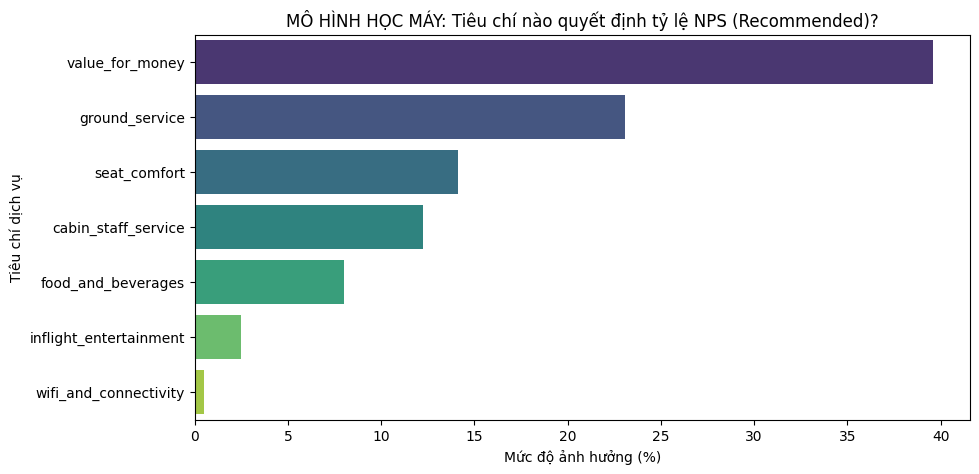

In [4]:
# Tìm "Trọng số vàng" bằng Machine Learning (Random Forest)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

#dataset
df_airline = pd.read_csv(DATA_PROCESSED / "airline_reviews_PBI_Master_Optimized_V3.csv")

# 1. Chuẩn hóa cột date_submitted về định dạng Datetime
df_airline["date_submitted"] = pd.to_datetime(df_airline["date_submitted"], errors="coerce")

# Xóa review trước 2009 VÀ chỉ giữ lại các review đã được xác thực (Verified)
df_airline = df_airline[
    (df_airline["date_submitted"].dt.year >= 2009) & 
    (df_airline["verify"] == 1)
].copy()

# 1. Chuẩn bị dữ liệu: Chọn 7 cột điểm số và cột mục tiêu (recommended)
# (Giả sử dataframe của bạn đang tên là df_airline)
features = [
    "seat_comfort",
    "cabin_staff_service",
    "food_and_beverages",
    "inflight_entertainment",
    "ground_service",
    "wifi_and_connectivity",
    "value_for_money",
]
target = "recommended"

# Lọc bỏ các dòng bị trống (NaN) trong 7 cột này để mô hình không báo lỗi
#df_ml = df_airline[features + [target]].dropna()

#print(f"✔️ Số lượng review đưa vào mô hình học máy: {len(df_ml):,} dòng")

# Sửa lại đoạn chuẩn bị dữ liệu: Thêm điều kiện lọc verified == True (hoặc 1 / 'True' tùy format data)
df_ml = df_airline[
    (df_airline['verify'] == 1) & 
    (df_airline[target].notnull())
][features + [target]].dropna()

print(f"✔️ Số lượng review ĐÃ XÁC THỰC đưa vào mô hình: {len(df_ml):,} dòng")
# Các bước huấn luyện X, y bên dưới giữ nguyên 100%


# 2. Khởi tạo và huấn luyện mô hình Random Forest
X = df_ml[features]
y = df_ml[target]

# Huấn luyện mô hình với 100 cây quyết định (n_estimators=100)
model = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=5
)
model.fit(X, y)

# 3. Lấy ra điểm số quan trọng của từng tiêu chí (Feature Importance)
importance_scores = pd.DataFrame(
    {"Dịch_vụ": features, "Độ_quan_trọng_%": model.feature_importances_ * 100}
).sort_values(by="Độ_quan_trọng_%", ascending=False)

# In bảng kết quả
print("\nBẢNG XẾP HẠNG ĐỘ QUAN TRỌNG CỦA CÁC DỊCH VỤ:")
print(importance_scores.to_string(index=False))

# 4. Vẽ biểu đồ trực quan hóa cho Power BI / Slide thuyết trình
plt.figure(figsize=(10, 5))
sns.barplot(
    data=importance_scores,
    x="Độ_quan_trọng_%",
    y="Dịch_vụ",
    palette="viridis",
)
plt.title("MÔ HÌNH HỌC MÁY: Tiêu chí nào quyết định tỷ lệ NPS (Recommended)?")
plt.xlabel("Mức độ ảnh hưởng (%)")
plt.ylabel("Tiêu chí dịch vụ")
plt.show()

BẢNG CHỨNG MINH HIỆU ỨNG HÀO QUANG (HALO EFFECT):
            nhom_mat_dat  seat_comfort  inflight_entertainment
 1. Mặt đất Tệ (1-2 sao)      1.771796                1.731597
2. Mặt đất Tốt (4-5 sao)      4.014332                3.767779


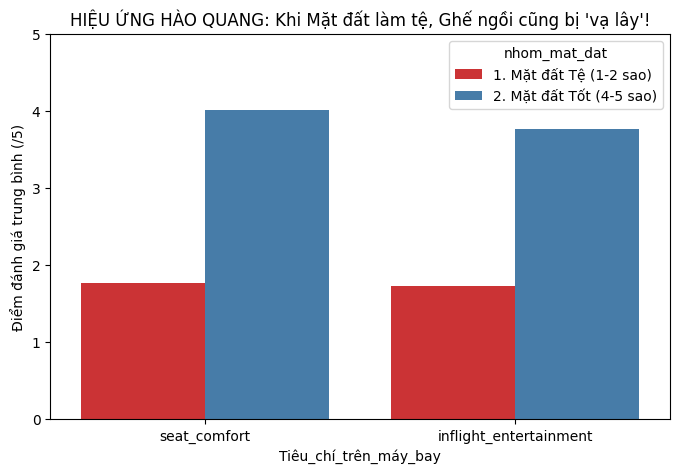

In [5]:
# Kiểm chứng Tâm lý học - "Hiệu ứng Hào quang" (Halo Effect)
# 1. Chia khách hàng thành 2 nhóm dựa trên Trải nghiệm mặt đất (Check-in/Hành lý/Gate)
df_airline["nhom_mat_dat"] = df_airline["ground_service"].apply(
    lambda x: "1. Mặt đất Tệ (1-2 sao)"
    if x <= 2
    else ("2. Mặt đất Tốt (4-5 sao)" if x >= 4 else "Bình thường")
)

# Chỉ lấy 2 nhóm Tệ và Tốt để so sánh đối lập
df_halo = df_airline[
    df_airline["nhom_mat_dat"].isin(
        ["1. Mặt đất Tệ (1-2 sao)", "2. Mặt đất Tốt (4-5 sao)"]
    )
]

# 2. Tính điểm trung bình của Ghế ngồi và Giải trí (2 yếu tố độc lập với mặt đất)
halo_summary = (
    df_halo.groupby("nhom_mat_dat")[
        ["seat_comfort", "inflight_entertainment"]
    ]
    .mean()
    .reset_index()
)

print("BẢNG CHỨNG MINH HIỆU ỨNG HÀO QUANG (HALO EFFECT):")
print(halo_summary.to_string(index=False))

# 3. Vẽ biểu đồ chứng minh sự tụt giảm bất hợp lý
plt.figure(figsize=(8, 5))
# Biến đổi bảng dữ liệu để vẽ biểu đồ cột cụm (Clustered Bar Chart)
df_melted = halo_summary.melt(
    id_vars="nhom_mat_dat",
    value_vars=["seat_comfort", "inflight_entertainment"],
    var_name="Tiêu_chí_trên_máy_bay",
    value_name="Điểm_trung_bình",
)

sns.barplot(
    data=df_melted,
    x="Tiêu_chí_trên_máy_bay",
    y="Điểm_trung_bình",
    hue="nhom_mat_dat",
    palette="Set1",
)
plt.title(
    "HIỆU ỨNG HÀO QUANG: Khi Mặt đất làm tệ, Ghế ngồi cũng bị 'vạ lây'!"
)
plt.ylabel("Điểm đánh giá trung bình (/5)")
plt.ylim(0, 5)
plt.show()

In [6]:
#Kiểm định Thống kê Toán học - Boeing vs. Airbus (T-test)
from scipy import stats

# 1. Tách tập dữ liệu điểm Ghế ngồi (seat_comfort) của 2 dòng máy bay
# Sử dụng hàm str.contains để tìm tên máy bay không phân biệt chữ hoa/thường
boeing_scores = df_airline[
    df_airline["aircraft"].str.contains("Boeing|B7", case=False, na=False)
]["seat_comfort"].dropna()

airbus_scores = df_airline[
    df_airline["aircraft"].str.contains("Airbus|A3", case=False, na=False)
]["seat_comfort"].dropna()

# In điểm số trung bình thực tế
print(
    f"✈️ Điểm ghế ngồi trung bình của BOEING: {boeing_scores.mean():.2f} (trên {len(boeing_scores):,} review)"
)
print(
    f"✈️ Điểm ghế ngồi trung bình của AIRBUS: {airbus_scores.mean():.2f} (trên {len(airbus_scores):,} review)"
)

# 2. Chạy kiểm định thống kê T-test (Independent Two-sample T-test)
t_stat, p_val = stats.ttest_ind(boeing_scores, airbus_scores, equal_var=False)

print("\n" + "=" * 50)
print("KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ (SCIPY STATS):")
print(f"- Chỉ số T-statistic: {t_stat:.4f}")
print(
    f"- Giá trị P-value: {p_val:.4f} (Quy chuẩn ngành toán: < 0.05 là có ý nghĩa)"
)
print("=" * 50)

# 3. Kết luận tự động bằng lời văn cho Data Analyst
if p_val < 0.05:
    better_plane = (
        "BOEING" if boeing_scores.mean() > airbus_scores.mean() else "AIRBUS"
    )
    print(
        f"🎯 KẾT LUẬN CHÍNH THỨC: Sự khác biệt là CÓ Ý NGHĨA THỐNG KÊ (Statistically Significant)!"
    )
    print(
        f"👉 Dòng máy bay {better_plane} thực sự mang lại trải nghiệm ghế ngồi thoải mái hơn."
    )
else:
    print(
        "🎯 KẾT LUẬN CHÍNH THỨC: Sự khác biệt KHÔNG có ý nghĩa thống kê (No Significant Difference)."
    )
    print(
        "👉 Điểm số chênh lệch chỉ là do ngẫu nhiên, hai dòng máy bay có chất lượng ghế ngồi tương đương nhau."
    )

✈️ Điểm ghế ngồi trung bình của BOEING: 3.17 (trên 9,551 review)
✈️ Điểm ghế ngồi trung bình của AIRBUS: 3.24 (trên 9,673 review)

KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ (SCIPY STATS):
- Chỉ số T-statistic: -3.2221
- Giá trị P-value: 0.0013 (Quy chuẩn ngành toán: < 0.05 là có ý nghĩa)
🎯 KẾT LUẬN CHÍNH THỨC: Sự khác biệt là CÓ Ý NGHĨA THỐNG KÊ (Statistically Significant)!
👉 Dòng máy bay AIRBUS thực sự mang lại trải nghiệm ghế ngồi thoải mái hơn.


In [7]:
## Phân cụm Chủ đề Tự động bằng AI (Topic Modeling - LDA)
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# 1. Lọc lấy cột từ khóa sạch của các review bị chê (recommended = 0)
neg_reviews = df_airline[df_airline["recommended"] == 0][
    "clean_keywords"
].dropna()
print(
    f"✔️ Đang phân tích chủ đề trên {len(neg_reviews):,} bài review tiêu cực..."
)

# 2. Biến đổi từ khóa thành ma trận số lượng (Count Vectorizer)
# Chỉ lấy các từ xuất hiện ít nhất 10 lần, tối đa 1000 từ phổ biến nhất
vectorizer = CountVectorizer(max_features=1000, min_df=10)
dtm = vectorizer.fit_transform(neg_reviews)

# 3. Chạy thuật toán LDA (Latent Dirichlet Allocation) để tìm 5 Chủ đề (Topics)
lda_model = LatentDirichletAllocation(
    n_components=5, random_state=42, max_iter=10
)
lda_model.fit(dtm)

# 4. Hiển thị Top 8 từ khóa cốt lõi đại diện cho từng Chủ đề
words = vectorizer.get_feature_names_out()

print("\n" + "=" * 60)
print("🔍 5 CHỦ ĐỀ PHÀN NÀN LỚN NHẤT PHÁT HIỆN BẰNG THUẬT TOÁN LDA:")
print("=" * 60)

for topic_idx, topic in enumerate(lda_model.components_):
    # Lấy ra 8 từ khóa có trọng số cao nhất trong cụm này
    top_words_idx = topic.argsort()[-8:][::-1]
    top_words = [words[i] for i in top_words_idx]
    print(f"📌 Chủ đề #{topic_idx + 1}: " + " | ".join(top_words))

print("-" * 60)
print("💡 HƯỚNG DẪN DA ĐỌC KẾT QUẢ:")
print(
    "Hãy nhìn vào cụm từ của từng Chủ đề để đặt tên nghiệp vụ cho nó. Ví dụ:"
)
print(" - Nếu thấy: 'luggage | lost | bag | checkin' -> Đặt tên: LỖI HÀNH LÝ")
print(
    " - Nếu thấy: 'delay | hour | waiting | gate'    -> Đặt tên: TRỄ CHUYẾN & CHỜ ĐỢI"
)

✔️ Đang phân tích chủ đề trên 44,549 bài review tiêu cực...

🔍 5 CHỦ ĐỀ PHÀN NÀN LỚN NHẤT PHÁT HIỆN BẰNG THUẬT TOÁN LDA:
📌 Chủ đề #1: delayed | airport | service | fly | never | customer | hotel | delay
📌 Chủ đề #2: staff | boarding | gate | airport | crew | check | board | seat
📌 Chủ đề #3: luggage | bag | check | baggage | pay | bags | carry | checked
📌 Chủ đề #4: seat | seats | service | class | food | business | economy | crew
📌 Chủ đề #5: refund | customer | ticket | service | booked | email | call | cancelled
------------------------------------------------------------
💡 HƯỚNG DẪN DA ĐỌC KẾT QUẢ:
Hãy nhìn vào cụm từ của từng Chủ đề để đặt tên nghiệp vụ cho nó. Ví dụ:
 - Nếu thấy: 'luggage | lost | bag | checkin' -> Đặt tên: LỖI HÀNH LÝ
 - Nếu thấy: 'delay | hour | waiting | gate'    -> Đặt tên: TRỄ CHUYẾN & CHỜ ĐỢI
